In [1]:
import polars as pl
import uproot
import matplotlib.pyplot as plt
import seaborn as sns
import datetime
from matplotlib import dates as mdates

In [2]:
data_path = "data/environment_data-08-03-2026-00_00_21.root"

In [4]:
root_file = uproot.open(data_path)
date_1970 = datetime.datetime(1970, 1, 1,1)
data = (
    pl.from_pandas(root_file["Vacuum"].arrays(['__timestamp_s','__timestamp_ns',"CC-Elena"],library='pd'))
    # .with_columns(pl.from_epoch("__timestamp_s", time_unit="ms"))
    .with_columns(date=pl.lit(date_1970) + pl.duration(seconds=pl.col("__timestamp_s")+pl.col("__timestamp_ns")/1e9))
)
print(data)


shape: (14_923, 4)
┌───────────────┬────────────────┬────────────┬─────────────────────┐
│ __timestamp_s ┆ __timestamp_ns ┆ CC-Elena   ┆ date                │
│ ---           ┆ ---            ┆ ---        ┆ ---                 │
│ f64           ┆ u32            ┆ f64        ┆ datetime[μs]        │
╞═══════════════╪════════════════╪════════════╪═════════════════════╡
│ 1.7729e9      ┆ 339959145      ┆ 6.2380e-10 ┆ 2026-03-08 00:00:36 │
│ 1.7729e9      ┆ 205952644      ┆ 6.2440e-10 ┆ 2026-03-08 00:01:06 │
│ 1.7729e9      ┆ 338684082      ┆ 6.2380e-10 ┆ 2026-03-08 00:01:36 │
│ 1.7729e9      ┆ 330225468      ┆ 6.2330e-10 ┆ 2026-03-08 00:02:06 │
│ 1.7729e9      ┆ 306396961      ┆ 6.2330e-10 ┆ 2026-03-08 00:02:36 │
│ …             ┆ …              ┆ …          ┆ …                   │
│ 1.7734e9      ┆ 18531322       ┆ 5.6700e-10 ┆ 2026-03-13 08:26:09 │
│ 1.7734e9      ┆ 111268044      ┆ 5.6600e-10 ┆ 2026-03-13 08:26:39 │
│ 1.7734e9      ┆ 243871212      ┆ 5.6700e-10 ┆ 2026-03-13 08:27:09 │
│

In [5]:
valve_state_data = (
    pl.read_csv("data/borealis_valve_test.dat",new_columns=["date","state"],has_header=False,try_parse_dates=True)
    .with_columns(pl.col("date").diff().alias("diff"))
    .with_columns(pl.when(pl.col("state")=="open").then(pl.col("diff").dt.total_seconds()).fill_null(strategy="backward"))
)
print(valve_state_data)
print(valve_state_data.select(pl.col("diff").unique()))

shape: (80, 3)
┌────────────────────────────┬───────┬──────┐
│ date                       ┆ state ┆ diff │
│ ---                        ┆ ---   ┆ ---  │
│ datetime[μs]               ┆ str   ┆ i64  │
╞════════════════════════════╪═══════╪══════╡
│ 2026-03-11 15:24:06.396336 ┆ open  ┆ 10   │
│ 2026-03-11 15:24:09.408775 ┆ close ┆ 10   │
│ 2026-03-11 15:24:19.409609 ┆ open  ┆ 10   │
│ 2026-03-11 15:24:22.420769 ┆ close ┆ 10   │
│ 2026-03-11 15:24:32.423808 ┆ open  ┆ 10   │
│ …                          ┆ …     ┆ …    │
│ 2026-03-11 17:35:01.177354 ┆ close ┆ 10   │
│ 2026-03-11 17:35:11.188471 ┆ open  ┆ 10   │
│ 2026-03-11 17:35:14.195573 ┆ close ┆ 10   │
│ 2026-03-11 17:35:24.206093 ┆ open  ┆ 10   │
│ 2026-03-11 17:35:27.217706 ┆ close ┆ null │
└────────────────────────────┴───────┴──────┘
shape: (11, 1)
┌──────┐
│ diff │
│ ---  │
│ i64  │
╞══════╡
│ null │
│ 10   │
│ 30   │
│ 60   │
│ 90   │
│ …    │
│ 435  │
│ 1060 │
│ 1405 │
│ 1442 │
│ 1925 │
└──────┘


2026-03-11 15:19:06.396336 2026-03-11 17:40:27.217706


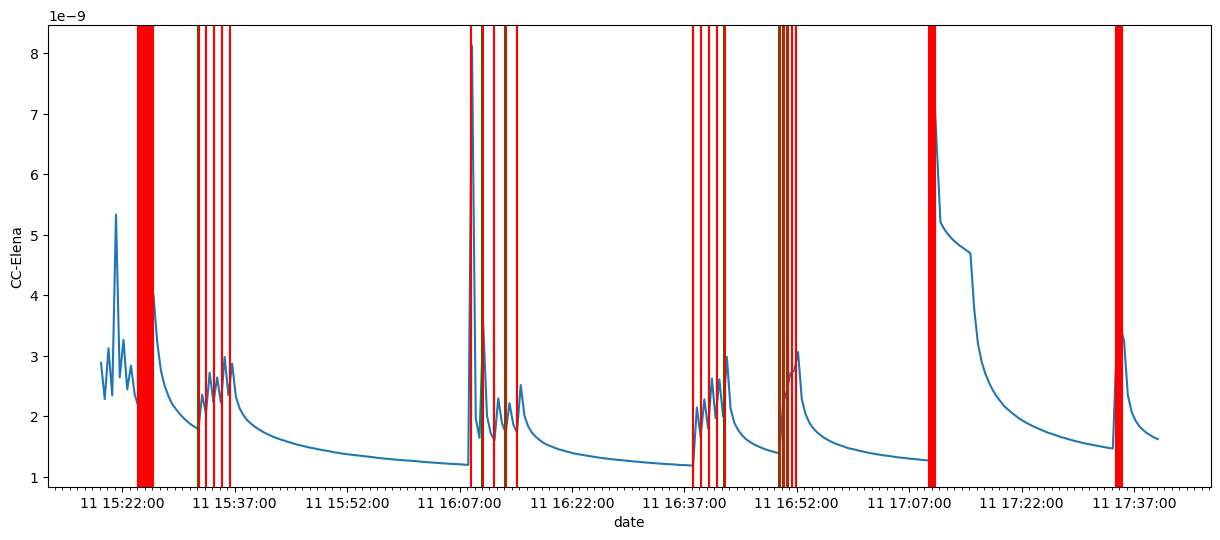

In [6]:
fig,ax = plt.subplots(figsize=(15,6))
valve_state = valve_state_data
start_time = valve_state.select(pl.col("date").first()).item() - datetime.timedelta(seconds=300)
stop_time = valve_state.select(pl.col("date").last()).item() + datetime.timedelta(seconds=300)
print(start_time,stop_time)

sns.lineplot(data.filter(pl.col("date").is_between(start_time,stop_time)),x="date",y="CC-Elena",ax=ax)
for time in pl.Series(valve_state.filter(pl.col("state")=="open")["date"]).to_list():
    ax.axvline(time,color="green")

for time in pl.Series(valve_state.filter(pl.col("state")=="close")["date"]).to_list():
    ax.axvline(time,color="red")

ax.xaxis.set_minor_locator(mdates.MinuteLocator())
ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %H:%M:%S'))

2026-03-11 16:44:42.257554 2026-03-11 16:56:51.327181
2026-03-11 15:27:11.047035 2026-03-11 16:47:21.113730
2026-03-11 16:03:31.513810 2026-03-11 16:19:40.579265


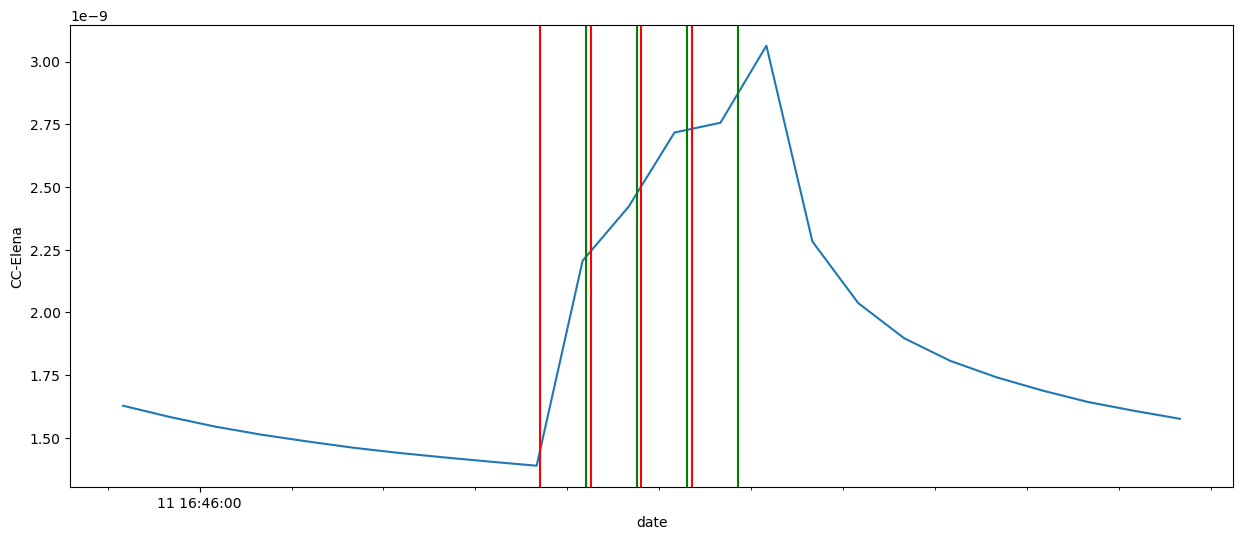

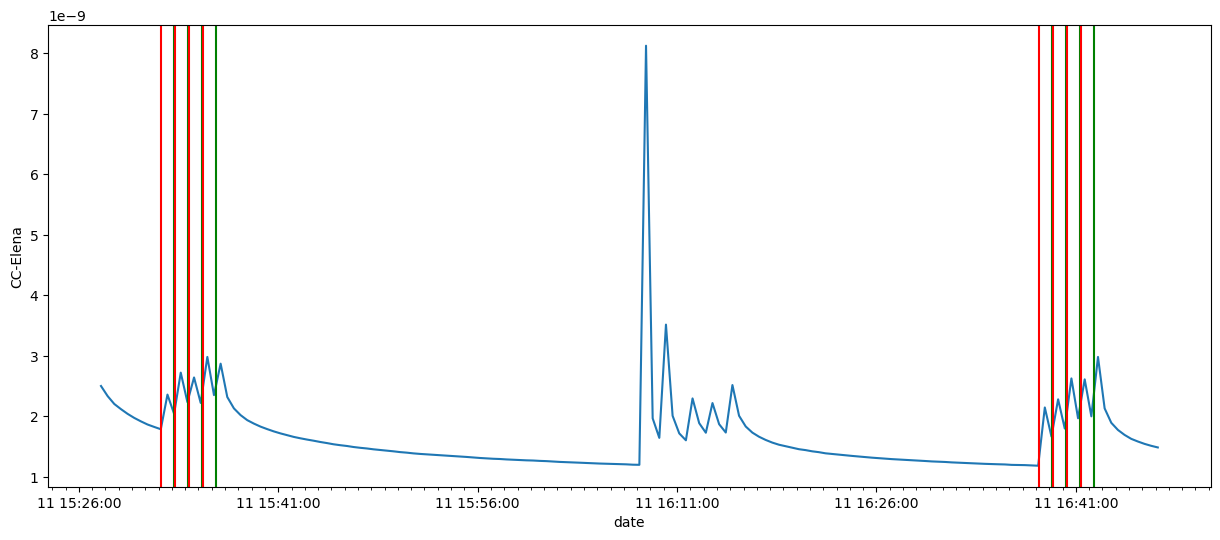

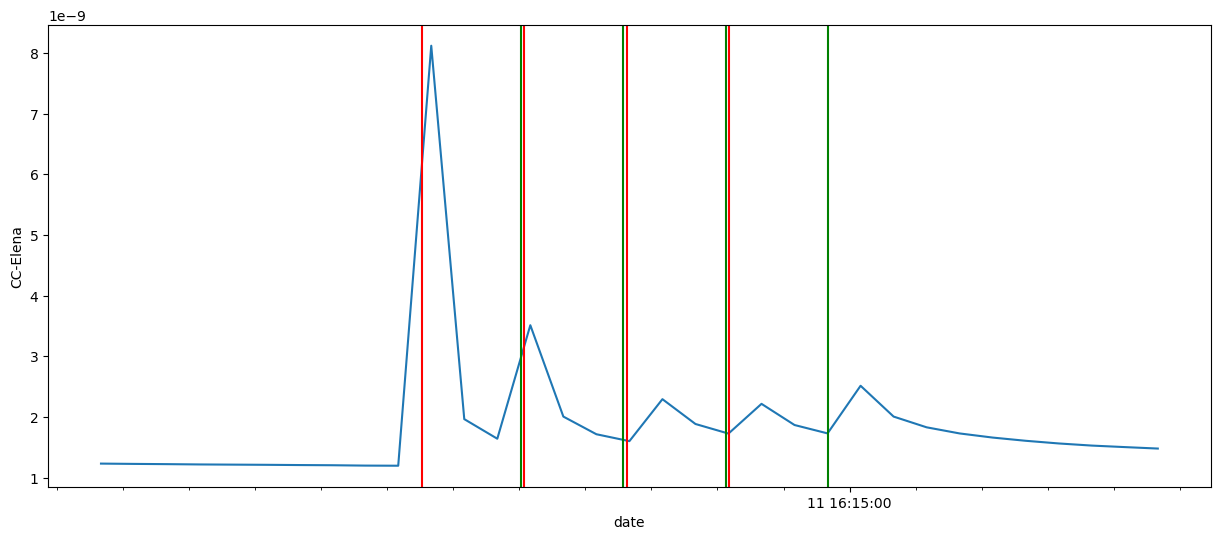

In [7]:
for delay in [30,60,90]:
    fig,ax = plt.subplots(figsize=(15,6))
    valve_state = valve_state_data.filter(pl.col("diff")==delay)
    start_time = valve_state.select(pl.col("date").first()).item() - datetime.timedelta(seconds=300)
    stop_time = valve_state.select(pl.col("date").last()).item() + datetime.timedelta(seconds=300)
    print(start_time,stop_time)

    sns.lineplot(data.filter(pl.col("date").is_between(start_time,stop_time)),x="date",y="CC-Elena",ax=ax)
    for time in pl.Series(valve_state.filter(pl.col("state")=="open")["date"]).to_list():
        ax.axvline(time,color="green")

    for time in pl.Series(valve_state.filter(pl.col("state")=="close")["date"]).to_list():
        ax.axvline(time,color="red")

    ax.xaxis.set_minor_locator(mdates.MinuteLocator())
    ax.xaxis.set_major_locator(mdates.MinuteLocator(interval=15))
    ax.xaxis.set_major_formatter(mdates.DateFormatter('%d %H:%M:%S'))

In [ ]:
for file in 